### **1. Import Libraries and Load Data**
First, we import the necessary libraries for data manipulation, visualization, and machine learning, and then load the cleaned telecom churn dataset.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

from sklearn.model_selection import (
    cross_val_score,
    RepeatedStratifiedKFold
)
from sklearn.model_selection import RepeatedStratifiedKFold

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/telecom_churn_cleaned.csv')
df.head()

,SeniorCitizen,Partner,Dependents,tenure,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,1,0,1,0,2,0,0,0,1,2,29.85,29.85,0
1,0,0,0,34,2,0,2,0,1,0,3,56.95,1889.50,0
2,0,0,0,2,2,2,0,0,0,1,3,53.85,108.15,1
3,0,0,0,45,2,0,2,2,1,0,0,42.30,1840.75,0
4,0,0,0,2,0,0,0,0,0,1,2,70.70,151.65,1


### **2. Feature Engineering**
We enhance the dataset by creating new features like `TotalServices` (count of active premium services), `TenureGroup` (binned tenure), and `AvgMonthlyCharge` (ratio of total to monthly charges) to provide better signals for the models.

In [ ]:
# 1. Total Services: Count of active premium services
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
# In this dataset, '2' usually represents 'Yes'. Let's count them.
df['TotalServices'] = (df[service_cols] == 2).sum(axis=1)

# 2. Tenure Binning
df['TenureGroup'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 100], labels=[0, 1, 2, 3], include_lowest=True).astype(int)

# 3. Average Monthly Charges (Charge density)
# Avoiding division by zero for tenure=0
df['AvgMonthlyCharge'] = df['TotalCharges'] / (df['tenure'] + 1)

print("New features added: TotalServices, TenureGroup, AvgMonthlyCharge")
display(df[['TotalServices', 'TenureGroup', 'AvgMonthlyCharge', 'Churn']].head())


New features added: TotalServices, TenureGroup, AvgMonthlyCharge


,TotalServices,TenureGroup,AvgMonthlyCharge,Churn
0,1,0,14.925000,0
1,2,2,53.985714,0
2,2,0,36.050000,1
3,3,2,40.016304,0
4,0,0,50.550000,1


### **3. Data Preprocessing and Imbalance Handling**
To address the class imbalance in the churn target, we use **SMOTETomek**, which combines over-sampling the minority class and under-sampling the majority class. We also scale the features to ensure uniform influence during training.

Since we have modified the underlying `df`, we need to re-run the preprocessing and resampling steps to include these new signals in our training data.

In [ ]:
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [ ]:
from sklearn.preprocessing import StandardScaler
from imblearn.combine import SMOTETomek

# Re-extract X and y to include new features
X = df.drop(columns=['Churn'])
y = df['Churn']

# Re-apply Resampling on the new feature set
smt = SMOTETomek(random_state=42)
X_smt, y_smt = smt.fit_resample(X, y)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_smt, y_smt, test_size=0.20, random_state=2)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features used for training:", X.columns.tolist())
print(y_train.value_counts())

Features used for training: ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'TotalServices', 'TenureGroup', 'AvgMonthlyCharge']
Churn
0    3845
1    3815
Name: count, dtype: int64


### **4. Model Training and Evaluation Utilities**
We define helper functions to streamline the training process, perform cross-validation, and generate standardized evaluation reports including ROC curves and confusion matrices.

In [ ]:
def model(classifier, x_train, y_train, x_test, y_test):

    classifier.fit(x_train, y_train)

    prediction = classifier.predict(x_test)

    cv = RepeatedStratifiedKFold(
        n_splits=10,
        n_repeats=3,
        random_state=1
    )

    cv_score = cross_val_score(
        classifier,
        x_train,
        y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    ).mean()

    print("Cross Validation Score :", "{0:.2%}".format(cv_score))
    print("ROC_AUC Score :", "{0:.2%}".format(roc_auc_score(y_test, prediction)))

    RocCurveDisplay.from_estimator(
        classifier,
        x_test,
        y_test
    )

    plt.title('ROC Curve')
    plt.show()

    return classifier

In [ ]:
def model_evaluation(classifier, x_test, y_test):

    pred = classifier.predict(x_test)

    cm = confusion_matrix(y_test, pred)

    names = ['TN','FP','FN','TP']
    counts = [value for value in cm.flatten()]
    percentages = ['{0:.2%}'.format(value) for value in cm.flatten()/np.sum(cm)]

    labels = [
        f'{v1}\n{v2}\n{v3}'
        for v1,v2,v3 in zip(names,counts,percentages)
    ]

    labels = np.asarray(labels).reshape(2,2)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=labels,
        cmap='Blues',
        fmt=''
    )

    plt.title('Confusion Matrix')
    plt.show()

    print(classification_report(y_test, pred))

### 5. **Baseline and Advanced Model Training**
In this section, we train and evaluate a series of classifiers, including Logistic Regression, Decision Trees, Random Forest, XGBoost, and a Stacking Ensemble, to identify the best-performing model.

Evaluating Logistic Regression:
Cross Validation Score : 89.74%
ROC_AUC Score : 80.83%


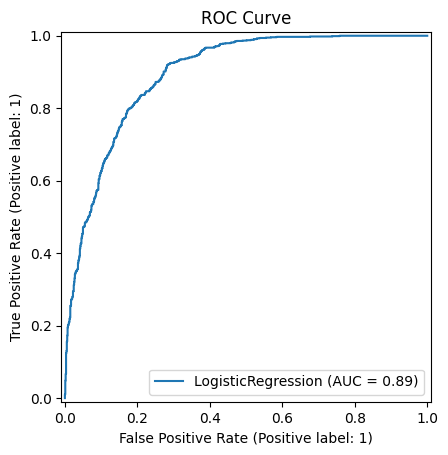

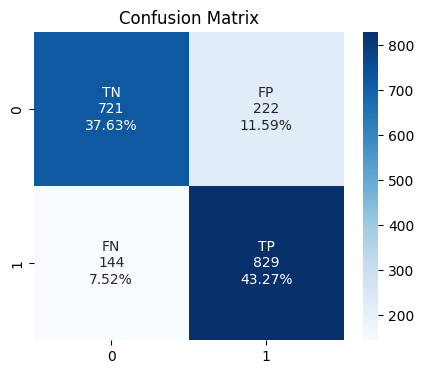

              precision    recall  f1-score   support

           0       0.83      0.76      0.80       943
           1       0.79      0.85      0.82       973

    accuracy                           0.81      1916
   macro avg       0.81      0.81      0.81      1916
weighted avg       0.81      0.81      0.81      1916



In [ ]:
from sklearn.linear_model import LogisticRegression

# Using the correctly scaled SMOTETomek data
lr = LogisticRegression(max_iter=1000, n_jobs=-1)

print("Evaluating Logistic Regression:")
model(lr, X_train_scaled, y_train, X_test_scaled, y_test)
model_evaluation(lr, X_test_scaled, y_test)

Cross Validation Score : 88.42%
ROC_AUC Score : 80.32%


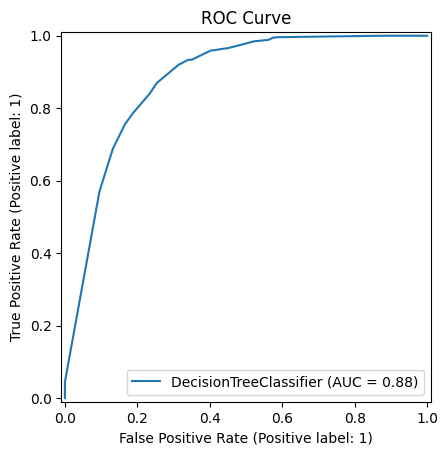

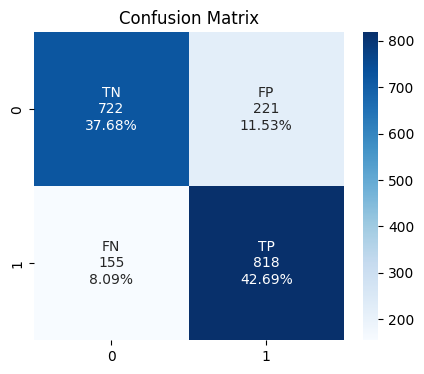

              precision    recall  f1-score   support

           0       0.82      0.77      0.79       943
           1       0.79      0.84      0.81       973

    accuracy                           0.80      1916
   macro avg       0.81      0.80      0.80      1916
weighted avg       0.80      0.80      0.80      1916



In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
)

model(dt, X_train_scaled, y_train, X_test_scaled, y_test)
model_evaluation(dt, X_test_scaled, y_test)

Cross Validation Score : 93.58%
ROC_AUC Score : 85.26%


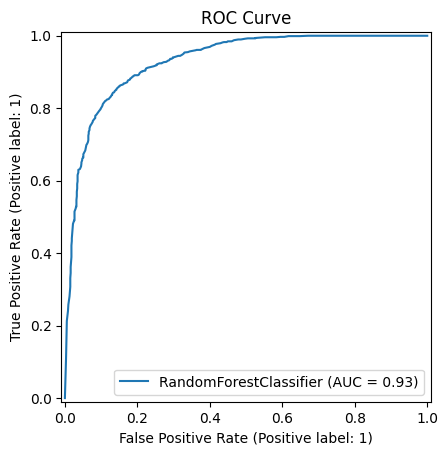

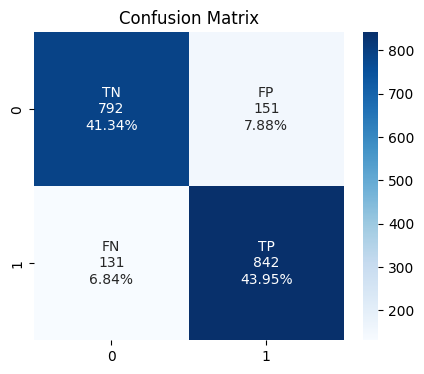

              precision    recall  f1-score   support

           0       0.86      0.84      0.85       943
           1       0.85      0.87      0.86       973

    accuracy                           0.85      1916
   macro avg       0.85      0.85      0.85      1916
weighted avg       0.85      0.85      0.85      1916



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model(rf, X_train_scaled, y_train, X_test_scaled, y_test)
model_evaluation(rf, X_test_scaled, y_test)

Evaluating XGBoost with Feature Engineering:
Cross Validation Score : 92.65%
ROC_AUC Score : 83.88%


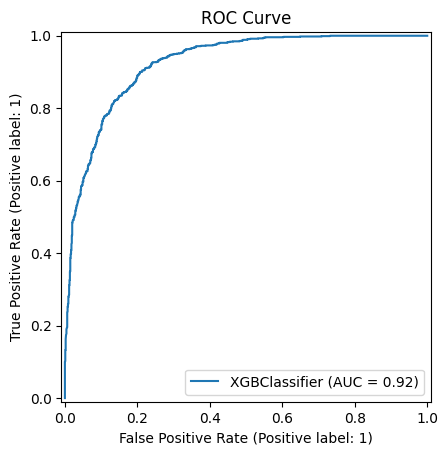

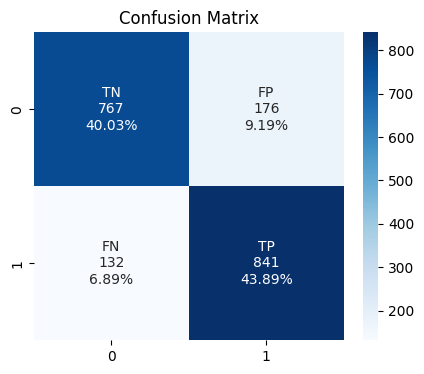

              precision    recall  f1-score   support

           0       0.85      0.81      0.83       943
           1       0.83      0.86      0.85       973

    accuracy                           0.84      1916
   macro avg       0.84      0.84      0.84      1916
weighted avg       0.84      0.84      0.84      1916



In [ ]:
from xgboost import XGBClassifier

# Re-train baseline XGBoost with new features
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

print("Evaluating XGBoost with Feature Engineering:")
model(xgb, X_train_scaled, y_train, X_test_scaled, y_test)
model_evaluation(xgb, X_test_scaled, y_test)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Cross Validation Score : 93.76%
ROC_AUC Score : 85.58%


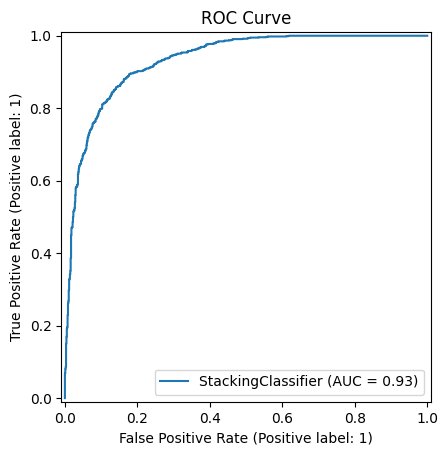

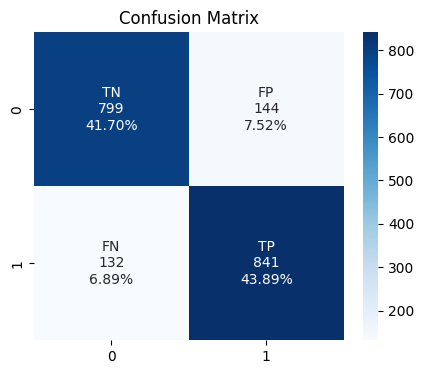

              precision    recall  f1-score   support

           0       0.86      0.85      0.85       943
           1       0.85      0.86      0.86       973

    accuracy                           0.86      1916
   macro avg       0.86      0.86      0.86      1916
weighted avg       0.86      0.86      0.86      1916



In [ ]:
from sklearn.ensemble import StackingClassifier

stack = StackingClassifier(
    estimators=[
        ('lr', lr),
        ('dt', dt),
        ('rf', rf),
        ('xgb', xgb)
    ],
    final_estimator=LogisticRegression(random_state=42),
    cv=5,
    n_jobs=-1
)

model(stack, X_train_scaled, y_train, X_test_scaled, y_test)
model_evaluation(stack, X_test_scaled, y_test)

In [ ]:
models = {
    'Logistic Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf,
    'XGBoost': xgb,
    'Stacking': stack
}

results = []

for name, clf in models.items():
    # Ensuring models are fitted on the current feature set
    clf.fit(X_train_scaled, y_train)
    pred = clf.predict(X_test_scaled)
    # Get probability scores for ROC AUC
    if hasattr(clf, "predict_proba"):
        prob = clf.predict_proba(X_test_scaled)[:, 1]
    else:
        prob = clf.decision_function(X_test_scaled)

    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred),
        roc_auc_score(y_test, prob)
    ])

results_df = pd.DataFrame(
    results,
    columns=['Model','Accuracy','Precision','Recall','F1', 'ROC_AUC']
)

display(results_df.sort_values(by='F1', ascending=False))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
4,Stacking,0.855950,0.853807,0.864337,0.859040,0.932603
2,Random Forest,0.852818,0.847936,0.865365,0.856562,0.930266
3,XGBoost,0.839248,0.826942,0.864337,0.845226,0.923950
0,Logistic Regression,0.808977,0.788773,0.852004,0.819170,0.893569
1,Decision Tree,0.803758,0.787295,0.840699,0.813121,0.877820


### **6. Combined ROC AUC Curve Comparison**
In this step, we plot the ROC curves for all classifiers on a single graph. This helps us visually verify which models have the highest area under the curve (AUC), representing superior classification performance.

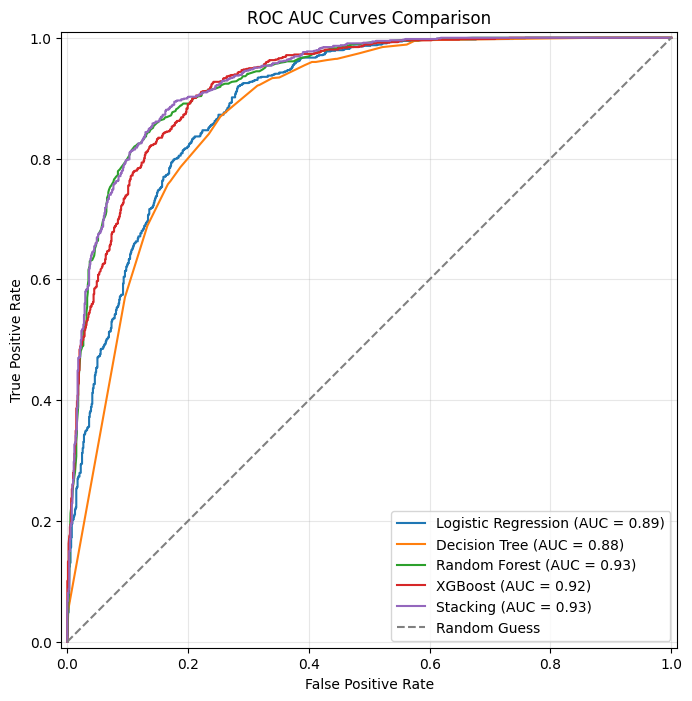

In [ ]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(10, 8))

# Dictionary of models to plot
model_list = {
    'Logistic Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf,
    'XGBoost': xgb,
    'Stacking': stack
}

# Plot each model's ROC curve on the same axes
for name, clf in model_list.items():
    RocCurveDisplay.from_estimator(clf, X_test_scaled, y_test, ax=ax, name=name)

plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random Guess')
plt.title('ROC AUC Curves Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

### **7. Model Interpretability**
We analyze feature importance to understand which variables drive the predictions

/tmp/ipykernel_7980/4145439102.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


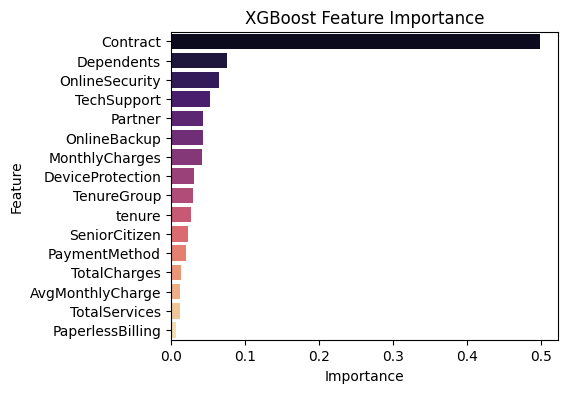

In [ ]:
# Get feature importances from the XGBoost model
importances = xgb.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(5, 4))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('XGBoost Feature Importance')
plt.show()

### **8. Export Models for Deployment**
We save our trained models and the scaler using `joblib` so they can be loaded into a Streamlit application for real-time inference.

In [ ]:
import joblib

# Save the best performing models
joblib.dump(stack, 'churn_model_stacking.pkl')
joblib.dump(rf, 'churn_model_rf.pkl')
joblib.dump(xgb, 'churn_model_xgboost.pkl')

# Crucial: Save the scaler to process new data during inference
joblib.dump(scaler, 'scaler.pkl')

print("Models and scaler saved successfully!")

Models and scaler saved successfully!


You can now download these `.pkl` files from the Colab file explorer on the left and upload them to your Streamlit project repository.